# MEx 1 — 3-Layer CNN for MNIST (einops/einsum)

**Course:** AI231 — Machine Learning Operations
**Node:** ai-n002.hpc.coe.upd.edu.ph (DGX, 8× A100-SXM4-40GB)
**Env:** vllm-env (PyTorch 2.13.0+cu130, einops 0.8.2, torchvision 0.28.0)

**Goal:** 3-layer CNN where every layer/operation uses `einops`/`einsum` (no `nn.Conv2d`/`nn.Linear`). Train 5 epochs, report test accuracy, visualize 16 test samples in a 4×4 grid (GT vs Pred).

**Architecture:**
```
input (B, 1, 28, 28)
  → Conv2d 1→32, k=3, s=1, p=1   [einsum unfold+matmul]  → ReLU → MaxPool 2×2 [einops]
  → Conv2d 32→64, k=3, s=1, p=1  [einsum unfold+matmul]  → ReLU → MaxPool 2×2 [einops]
  → Flatten [einops rearrange]
  → Linear 7×7×64→128            [einsum matmul]          → ReLU
  → Linear 128→10                 [einsum matmul]
```

In [1]:
import os, sys, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, reduce
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__} (CUDA: {torch.version.cuda})")
import einops
print(f"einops: {einops.__version__}")
import torchvision
print(f"torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")

Python: 3.12.14
PyTorch: 2.13.0+cu130 (CUDA: 13.0)
einops: 0.8.2
torchvision: 0.28.0+cu130
CUDA available: True
GPU count: 8


In [2]:
# --- GPU selection: pick the freest GPU via nvidia-smi ---
import subprocess
out = subprocess.check_output(
    ['nvidia-smi', '--query-gpu=index,memory.used', '--format=csv,noheader,nounits'], text=True
)
gpus = [(int(l.split(',')[0]), int(l.split(',')[1].strip())) for l in out.strip().split('\n')]
free_idx, free_mem = min(gpus, key=lambda x: x[1])
os.environ['CUDA_VISIBLE_DEVICES'] = str(free_idx)
device = torch.device('cuda')
print(f"Pinned to physical GPU {free_idx} ({free_mem} MiB used) -> visible as cuda:0")
print(f"Device: {device} ({torch.cuda.get_device_name(0)})")

Pinned to physical GPU 0 (4 MiB used) -> visible as cuda:0
Device: cuda (NVIDIA A100-SXM4-40GB)


In [3]:
# --- Data ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)
print(f"Train: {len(train_ds)}  |  Test: {len(test_ds)}")
print(f"Sample shape: {train_ds[0][0].shape}, label: {train_ds[0][1]} (type={type(train_ds[0][1]).__name__})")

Train: 60000  |  Test: 10000


Sample shape: torch.Size([1, 28, 28]), label: 5 (type=int)


In [4]:
# ============================================================
# Custom layers — all einops/einsum, zero nn.Conv2d / nn.Linear
# ============================================================

class EinConv2d(nn.Module):
    """Conv2d via unfold + einsum. Weight: (Cin, Cout, k, k)."""
    def __init__(self, cin, cout, k, stride=1, padding=0):
        super().__init__()
        self.k, self.stride, self.padding = k, stride, padding
        fan_in = cin * k * k
        self.weight = nn.Parameter(torch.empty(cin, cout, k, k))
        self.bias   = nn.Parameter(torch.zeros(cout))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        nn.init.uniform_(self.bias, -1/np.sqrt(fan_in), 1/np.sqrt(fan_in))

    def forward(self, x):
        # x: (B, Cin, H, W)
        if self.padding:
            x = F.pad(x, (self.padding,) * 4)
        # unfold: (B, Cin, H_out, W_out, k, k)
        x_unf = x.unfold(2, self.k, self.stride).unfold(3, self.k, self.stride)
        # einops: (B, Cin, H_out, W_out, k, k) -> (B, H_out, W_out, Cin*k*k)
        x_unf = rearrange(x_unf, 'b c h w i j -> b h w (c i j)')
        # weight: (Cin, Cout, k, k) -> (Cin*k*k, Cout)
        w = rearrange(self.weight, 'c o i j -> (c i j) o')
        # einsum: (B, H_out, W_out, Cin*k*k) @ (Cin*k*k, Cout) -> (B, H_out, W_out, Cout)
        out = torch.einsum('bhwd,do->bhwo', x_unf, w) + self.bias
        # back to channels-first
        return rearrange(out, 'b h w c -> b c h w')


class EinMaxPool(nn.Module):
    """MaxPool 2x2 via einops rearrange + reduce."""
    def forward(self, x):
        # x: (B, C, H, W) -> (B, C, H/2, W/2); the fixed '2' is the INNER index
        # so each group is a contiguous 2x2 neighborhood (verified == nn.MaxPool2d(2)).
        return reduce(x, 'b c (h 2) (w 2) -> b c h w', reduction='max')


class EinLinear(nn.Module):
    """Linear via einsum. Weight: (in_f, out_f)."""
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_f, out_f))
        self.bias   = nn.Parameter(torch.zeros(out_f))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        nn.init.uniform_(self.bias, -1/np.sqrt(in_f), 1/np.sqrt(in_f))

    def forward(self, x):
        # x: (..., in_f) -> (..., out_f)
        return torch.einsum('...i,io->...o', x, self.weight) + self.bias


class CNN3(nn.Module):
    """3-layer CNN: all einops/einsum."""
    def __init__(self):
        super().__init__()
        self.conv1 = EinConv2d(1, 32, k=3, padding=1)    # 28x28 -> 28x28
        self.pool1 = EinMaxPool()                         # 28x28 -> 14x14
        self.conv2 = EinConv2d(32, 64, k=3, padding=1)   # 14x14 -> 14x14
        self.pool2 = EinMaxPool()                         # 14x14 -> 7x7
        self.fc1   = EinLinear(7*7*64, 128)              # 3136 -> 128
        self.fc2   = EinLinear(128, 10)                   # 128 -> 10

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = rearrange(x, 'b c h w -> b (c h w)')          # flatten via einops
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN3().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model}")
print(f"Total parameters: {n_params:,}")

Model: CNN3(
  (conv1): EinConv2d()
  (pool1): EinMaxPool()
  (conv2): EinConv2d()
  (pool2): EinMaxPool()
  (fc1): EinLinear()
  (fc2): EinLinear()
)
Total parameters: 421,642


In [5]:
# --- Training ---
BATCH = 128
EPOCHS = 5
LR = 1e-3

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler()

history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                logits = model(xb)
            preds = logits.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return 100.0 * correct / total

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_acc = 100.0 * correct / total
    test_acc  = evaluate(test_loader)
    elapsed   = time.time() - t0
    history['train_loss'].append(running_loss / total)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    print(f"Epoch {epoch}/{EPOCHS}  loss={running_loss/total:.4f}  "
          f"train_acc={train_acc:.2f}%  test_acc={test_acc:.2f}%  "
          f"({elapsed:.1f}s elapsed)")

print(f"\nTotal training time: {time.time()-t0:.1f}s")
print(f"Final test accuracy: {history['test_acc'][-1]:.2f}%")

/tmp/ipykernel_1181120/3628808133.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1181120/3628808133.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


/tmp/ipykernel_1181120/3628808133.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5  loss=0.2011  train_acc=93.76%  test_acc=98.26%  (12.9s elapsed)


Epoch 2/5  loss=0.0507  train_acc=98.41%  test_acc=98.94%  (23.8s elapsed)


Epoch 3/5  loss=0.0336  train_acc=98.92%  test_acc=99.00%  (34.5s elapsed)


Epoch 4/5  loss=0.0255  train_acc=99.20%  test_acc=99.20%  (45.2s elapsed)


Epoch 5/5  loss=0.0201  train_acc=99.41%  test_acc=99.10%  (56.0s elapsed)

Total training time: 56.0s
Final test accuracy: 99.10%


/tmp/ipykernel_1181120/2421711094.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


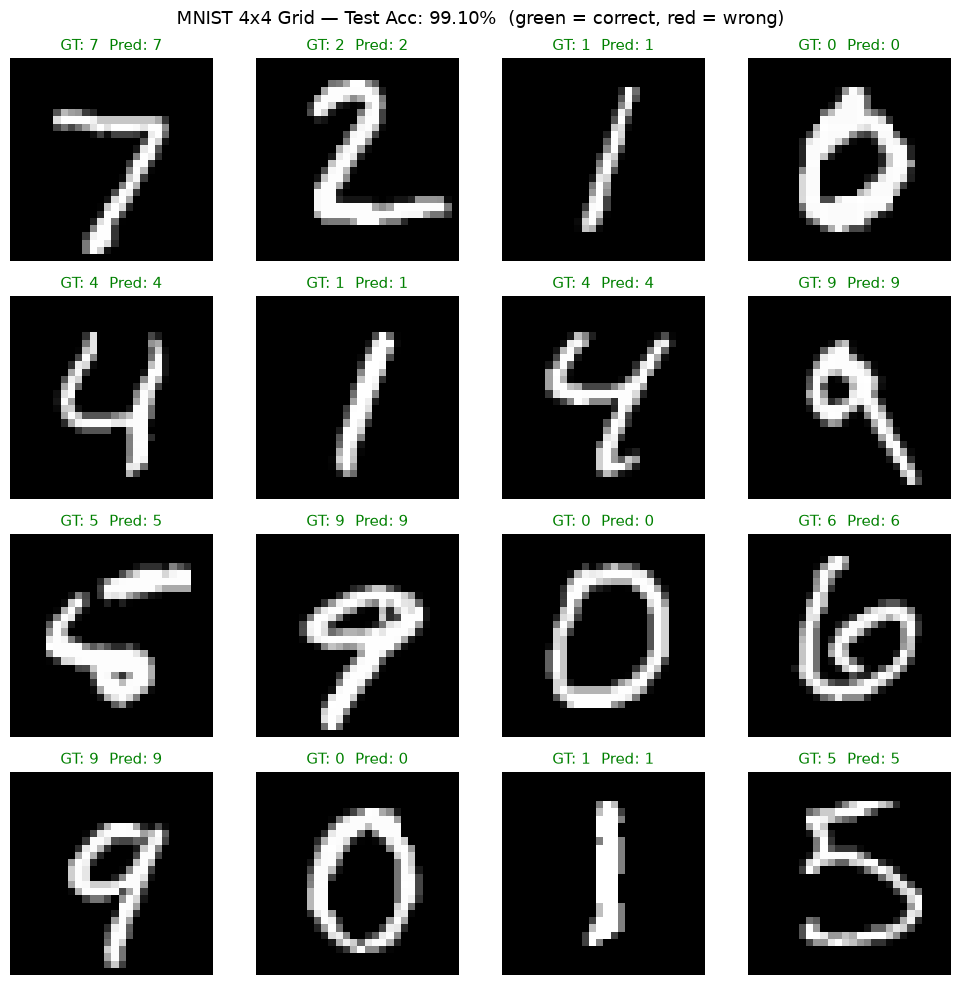

Grid accuracy: 16/16 = 100.0%


In [6]:
# --- 4x4 grid: 16 test images, GT vs Pred ---
model.eval()
xb, yb = next(iter(test_loader))
xb, yb = xb[:16].to(device), yb[:16]

with torch.no_grad():
    with torch.cuda.amp.autocast():
        logits = model(xb)
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(1).cpu().numpy()
    truth = yb.numpy()
    imgs  = xb.cpu().numpy()

# Denormalize for display
imgs = np.clip(imgs * 0.3081 + 0.1307, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, img, t, p in zip(axes.ravel(), imgs, truth, preds):
    ax.imshow(img[0], cmap='gray')
    color = 'green' if t == p else 'red'
    ax.set_title(f"GT: {t}  Pred: {p}", color=color, fontsize=11)
    ax.axis('off')
fig.suptitle(f"MNIST 4x4 Grid — Test Acc: {history['test_acc'][-1]:.2f}%  "
             f"(green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.savefig('grid_4x4.png', dpi=100, bbox_inches='tight')

# Embed the figure inline (works headless: renders PNG bytes directly)
from IPython.display import Image, display
display(Image(filename='grid_4x4.png'))
plt.close(fig)

n_correct = int((preds == truth).sum())
print(f"Grid accuracy: {n_correct}/16 = {100*n_correct/16:.1f}%")

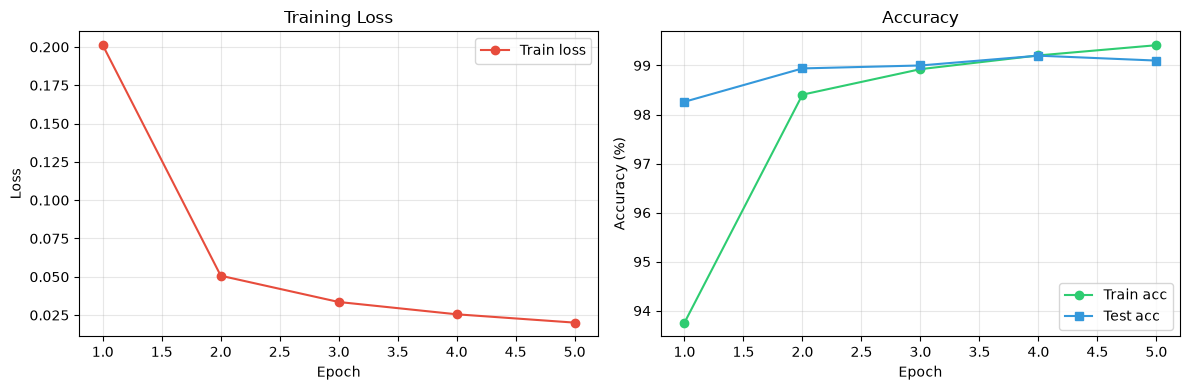

In [7]:
# --- Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], 'o-', color='#e74c3c', label='Train loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs, history['train_acc'], 'o-', color='#2ecc71', label='Train acc')
ax2.plot(epochs, history['test_acc'],  's-', color='#3498db', label='Test acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curves.png', dpi=100, bbox_inches='tight')

# Embed the figure inline (works headless: renders PNG bytes directly)
from IPython.display import Image, display
display(Image(filename='curves.png'))
plt.close(fig)